Here is the complete set of notebook notes, combining all the concepts, mathematics, and code into one cohesive flow. You can copy and paste these directly into your Jupyter Notebook cells.

---

### **[Markdown Cell]**

# PyTorch Autograd: Automatic Differentiation

**Autograd** is PyTorch’s built-in automatic differentiation engine. It powers neural network training by automatically calculating the gradients (derivatives) of a computation with respect to its inputs.

When training a neural network, algorithms like gradient descent need to know how much each weight and bias contributed to the final error. Autograd calculates this backward step automatically.

### Core Concepts

* **`requires_grad=True`**: When you create a tensor and set this attribute to `True`, PyTorch starts tracking every operation performed on that tensor.
* **Computational Graph**: PyTorch builds a Directed Acyclic Graph (DAG) under the hood. Tensors are the nodes, and the mathematical operations (functions) are the edges.
* **`.backward()`**: When you finish your computation, you call this method on the final tensor (usually the loss). Autograd then traverses the graph backward to compute all gradients.
* **`.grad`**: The computed gradients are stored in this attribute of the original tensors.

---

### **[Code Cell]**

```python
import torch

# 1. Create tensors with requires_grad=True to track computations
x = torch.tensor(2.0, requires_grad=True)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(4.0, requires_grad=True)

# 2. Perform a forward pass (computation)
# Equation: y = w * x + b
y = w * x + b 

print(f"Result of y: {y.item()}")

# 3. Perform a backward pass to calculate gradients
y.backward()

# 4. View the gradients (dy/dw, dy/dx, dy/db)
print(f"Gradient w.r.t x (dy/dx = w): {x.grad}")
print(f"Gradient w.r.t w (dy/dw = x): {w.grad}")
print(f"Gradient w.r.t b (dy/db = 1): {b.grad}")

```

---

### **[Markdown Cell]**

## Stopping Autograd (Inference Mode)

You don't always want PyTorch to track gradients. Tracking operations consumes memory and computational power. When you are evaluating a model, making predictions (inference), or fine-tuning only specific layers, you should turn Autograd off.

**Ways to stop tracking:**

1. **`torch.no_grad()`**: A context manager that disables gradient calculation for a block of code.
2. **`.detach()`**: Creates a new tensor that shares the same data but is detached from the computational graph.

> **Important Note:** PyTorch accumulates gradients. If you run `.backward()` multiple times in a loop (like during training), the new gradients are added to the old ones. You must clear them using `optimizer.zero_grad()` or `tensor.grad.zero_()` before the next pass.

---

### **[Code Cell]**

```python
# --- Using torch.no_grad() ---
x = torch.tensor([1.0, 2.0], requires_grad=True)

with torch.no_grad():
    # PyTorch ignores requires_grad inside this block
    y = x * 2
    print(f"Does y require grad? {y.requires_grad}") # Will be False

# --- Using .detach() ---
z = x * 3
z_detached = z.detach()

print(f"Does z require grad? {z.requires_grad}")          # Will be True
print(f"Does z_detached require grad? {z_detached.requires_grad}") # Will be False

```

---



### **[Markdown Cell]**

## The Mathematics of Autograd: The Chain Rule

At its core, PyTorch Autograd is an engine that automatically applies the **Chain Rule** from calculus. Let's look at a composite function:

1. $y = x^2$
2. $z = \sin(y)$
3. $u = e^z$

If we want to find how a change in our initial input $x$ affects our final output $u$, we need to calculate the derivative of $u$ with respect to $x$, denoted as $\frac{du}{dx}$.

Because $u$ is built from a sequence of functions, we use the Chain Rule, which states:


$$\frac{du}{dx} = \frac{du}{dz} \cdot \frac{dz}{dy} \cdot \frac{dy}{dx}$$

Let's calculate the local derivatives for each step:

* **Step 1:** $\frac{dy}{dx} = 2x$
* **Step 2:** $\frac{dz}{dy} = \cos(y)$
* **Step 3:** $\frac{du}{dz} = e^z$

Combining them gives us our final analytical gradient:


$$\frac{du}{dx} = e^z \cdot \cos(y) \cdot 2x$$

---

### **[Code Cell]**

```python
import math
import torch

# ==========================================
# 1. MANUAL CALCULATION (Without Autograd)
# ==========================================
print("--- Manual Chain Rule Differentiation ---")

x_val = 2.0
y_val = x_val ** 2
z_val = math.sin(y_val)
u_val = math.exp(z_val)

# Backward Pass (Chain Rule)
dy_dx = 2 * x_val
dz_dy = math.cos(y_val)
du_dz = math.exp(z_val)
du_dx = du_dz * dz_dy * dy_dx

print(f"Manual Gradient (du/dx): {du_dx:.4f}\n")

# ==========================================
# 2. PYTORCH AUTOGRAD CALCULATION
# ==========================================
print("--- PyTorch Autograd Differentiation ---")

x = torch.tensor(2.0, requires_grad=True)

# Forward Pass (Graph is built)
y = x ** 2
z = torch.sin(y)
u = torch.exp(z)

# Backward Pass (Chain rule is automated)
u.backward()

print(f"Autograd Gradient (du/dx): {x.grad.item():.4f}")

```

---

### **[Markdown Cell]**

## Types of Differentiation in Autograd

While standard backpropagation is the most common, PyTorch's Autograd ecosystem handles different algorithmic approaches depending on data shape:

### 1. Reverse-Mode Automatic Differentiation (Default)

Computes the forward pass to get the output, then works backwards from the output to the inputs to compute gradients.

* **Best for:** Functions with **many inputs and one output** (e.g., standard neural network loss).
* **Mechanism:** Computes Vector-Jacobian Products (VJPs).

### 2. Forward-Mode Automatic Differentiation

Calculates derivatives simultaneously with the forward pass, going from inputs to outputs.

* **Best for:** Functions with **few inputs and many outputs**.
* **Mechanism:** Computes Jacobian-Vector Products (JVPs).

---

### **[Markdown Cell]**

## A Practical Example: Single Neuron Training Loop

Let's apply Autograd to a practical scenario: a simple neural network predicting whether a student gets placed (1 or 0) based on their CGPA.

The standard deep learning **Training Process** has 4 steps:

1. **Forward pass:** Compute the output of the network given an input.
2. **Calculate loss:** Calculate the loss function to quantify the error.
3. **Backward pass:** Compute gradients of the loss with respect to the parameters using Autograd.
4. **Update gradients:** Adjust the parameters using an optimization algorithm (like Gradient Descent).

### The Mathematical Model (Logistic Regression)

1. **Linear Transformation:** Computes the weighted sum of inputs plus a bias.

$$z = w \cdot x + b$$


2. **Activation (Sigmoid Function):** Squeezes the linear output into a probability between 0 and 1.

$$y_{\text{pred}} = \sigma(z) = \frac{1}{1 + e^{-z}}$$


3. **Loss Function (Binary Cross-Entropy Loss):** Compares the predicted probability to the actual target.

$$L = - [y_{\text{target}} \cdot \ln(y_{\text{pred}}) + (1 - y_{\text{target}}) \cdot \ln(1 - y_{\text{pred}})]$$



---

### **[Code Cell]**

```python
import torch

# Data: CGPA = 9.11, Placed = 1
x = torch.tensor([9.11])       
y_target = torch.tensor([1.0]) 

# Initialize parameters with requires_grad=True
w = torch.tensor([0.1], requires_grad=True) 
b = torch.tensor([-0.5], requires_grad=True)

learning_rate = 0.01

print(f"Initial w: {w.item():.4f}, b: {b.item():.4f}\n")

# STEP 1: FORWARD PASS
z = w * x + b
y_pred = 1 / (1 + torch.exp(-z)) 
print(f"Predicted Probability: {y_pred.item():.4f} (Target is 1.0)")

# STEP 2: CALCULATE LOSS
eps = 1e-7 # Prevent log(0)
loss = - (y_target * torch.log(y_pred + eps) + (1 - y_target) * torch.log(1 - y_pred + eps))
print(f"Loss (L): {loss.item():.4f}\n")

# STEP 3: BACKWARD PASS
loss.backward()

print("--- Gradients Computed by Autograd ---")
print(f"dL/dw: {w.grad.item():.4f}")
print(f"dL/db: {b.grad.item():.4f}\n")

# STEP 4: UPDATE PARAMETERS (Gradient Descent)
with torch.no_grad():
    w -= learning_rate * w.grad
    b -= learning_rate * b.grad
    
    # ZERO OUT GRADIENTS
    w.grad.zero_()
    b.grad.zero_()

print("--- After Parameter Update ---")
print(f"Updated w: {w.item():.4f}, b: {b.item():.4f}")

```

---

Would you like me to write a final cell showing how to replace the manual mathematical equations and parameter updates with PyTorch's built-in `torch.nn.Linear`, `torch.nn.BCELoss`, and `torch.optim.SGD`? This is how it's done in production!

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

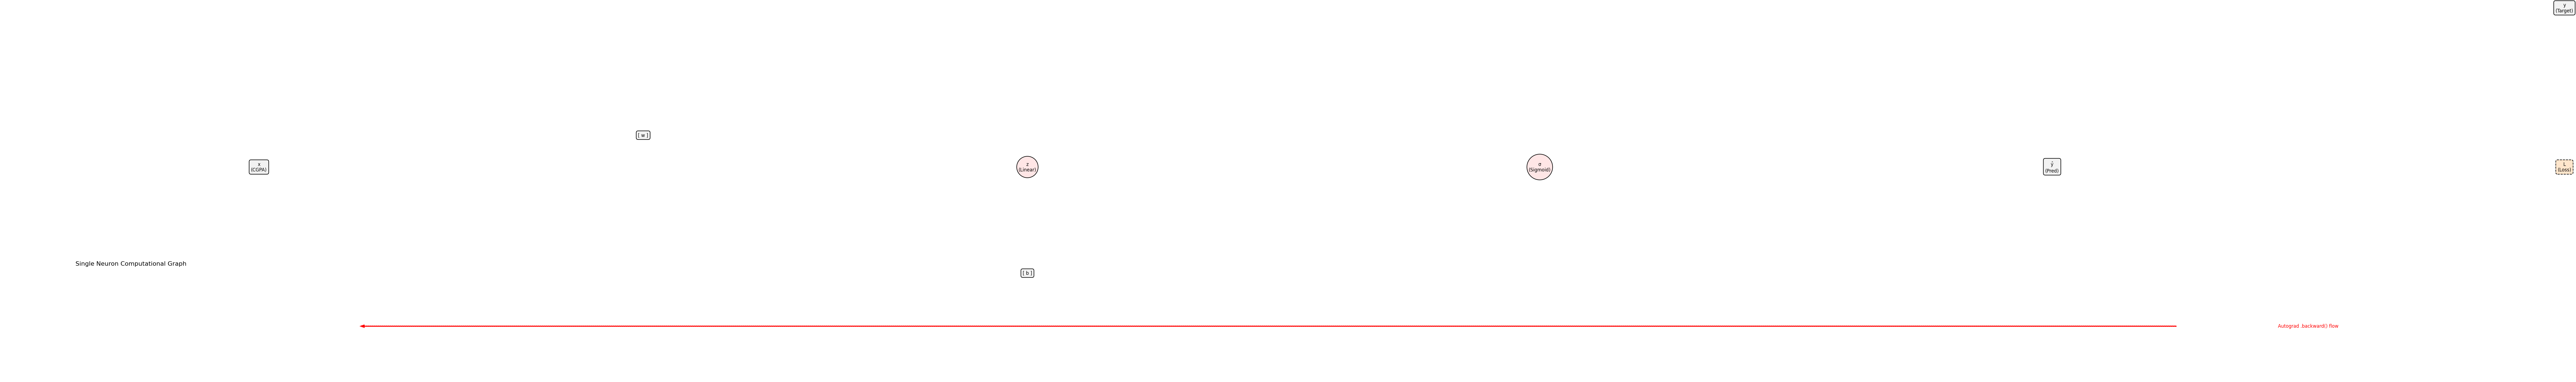